## Import Libraries and load data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import joblib
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Cleaned_data.csv')

## Prepare data

In [ ]:
df.head()

,Unnamed: 0,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,...,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI,TrainingLevel,Sleep_Category,Matches_Load,Injury_History,Nutrition_Category,Injury_Status
0,0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,...,81.472206,1,0,21.383942,High,Normal,Very High,Few Injuries,Good,No Injury
1,1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,...,81.056677,1,0,23.183391,High,Normal,Very High,Few Injuries,Good,No Injury
2,2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,...,64.877457,0,1,21.678807,High,Normal,Low,Few Injuries,Average,Injured
3,3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,...,89.824744,1,0,20.957274,Moderate,Normal,Low,Few Injuries,Good,No Injury
4,4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,...,71.569197,0,1,31.773932,High,Poor,Low,Few Injuries,Average,Injured


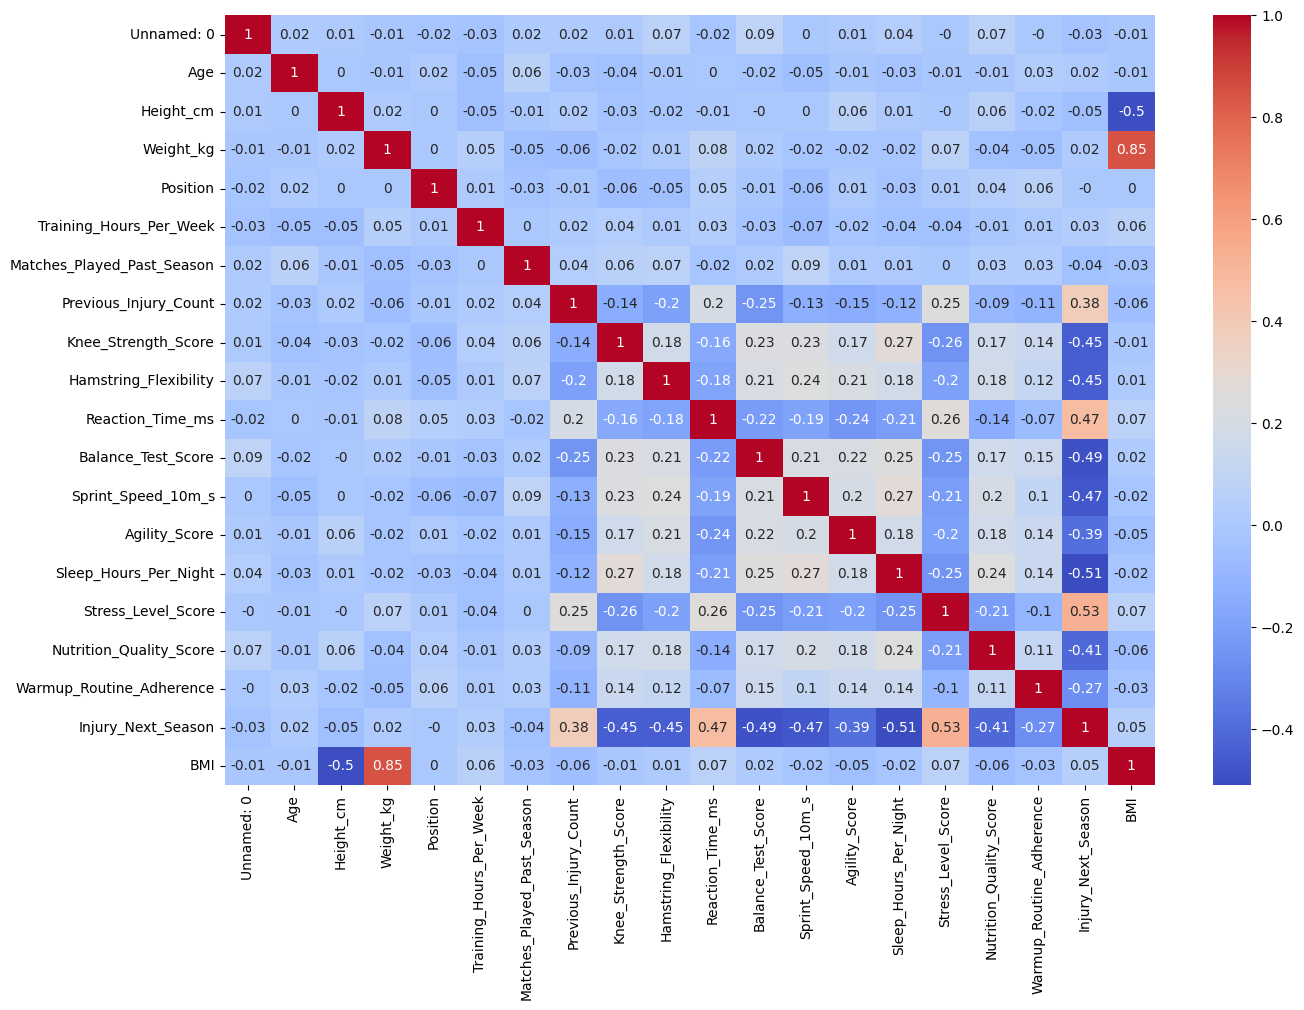

In [35]:
#heatmap for correlations
cor= df.select_dtypes(include='number').corr().round(2)
plt.figure(figsize=(15,10))
sns.heatmap(cor,annot=True,cmap="coolwarm")
plt.show()

In [ ]:
# label encoding for category column
le = LabelEncoder()
df["Position"] = le.fit_transform(df["Position"])

In [ ]:
# choose only the columns that affects on the target (we know them from the heatmap(corr))
X=df[["Stress_Level_Score","Sleep_Hours_Per_Night","Balance_Test_Score","Reaction_Time_ms",
    "Sprint_Speed_10m_s","Knee_Strength_Score","Hamstring_Flexibility","Nutrition_Quality_Score","Agility_Score",
    "Previous_Injury_Count","Warmup_Routine_Adherence","Position"]]
y=df['Injury_Next_Season']

In [ ]:
#split the data
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=45)

In [ ]:
s=StandardScaler()

In [ ]:
# scailing numeric colummns
x_train_s=s.fit_transform(x_train)
x_test_s=s.fit_transform(x_test)

In [ ]:
k_values=[1,3,5,7,9,11,13,15]
best_k,best_acc=None,0

In [ ]:
#find best K
for k in k_values:
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(x_train_s,y_train)
  y_pred=model.predict(x_test_s)
  acc=accuracy_score(y_test,y_pred)
  print(f"K={k} --> Accuracy :{acc}")
  if acc>best_acc:
    best_acc,best_k=acc,k
print(best_acc,best_k)

K=1 --> Accuracy :0.9166666666666666
K=3 --> Accuracy :0.9416666666666667
K=5 --> Accuracy :0.95
K=7 --> Accuracy :0.9458333333333333
K=9 --> Accuracy :0.9458333333333333
K=11 --> Accuracy :0.9541666666666667
K=13 --> Accuracy :0.95
K=15 --> Accuracy :0.95
0.9541666666666667 11


In [ ]:
# final model
final_model=KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train_s,y_train)
y_pred=final_model.predict(x_test_s)
acc=accuracy_score(y_test,y_pred)

In [ ]:
acc

0.9541666666666667

In [ ]:
confusion_matrix(y_test,y_pred)

array([[113,   1],
       [ 10, 116]])

In [ ]:
#save the model and preprocessing steps
joblib.dump(final_model,"Preict_injurey_model.pkl")
joblib.dump(le,"leabel_encoder.pkl")
joblib.dump(s,"scaler.pkl")

['scaler.pkl']